In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import gudhi

from shapediscover import ShapeDiscoverLite, FuzzyCoverPersistence, plot_nerve
from synthetic_data import sphere
from plotting_and_preprocessing import plot_and_return_2d_embedding

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Sphere

In [70]:
X = sphere(2000, 2)
coverer = ShapeDiscoverLite(25)
fuzzy_cover = coverer.fit_transform(X)

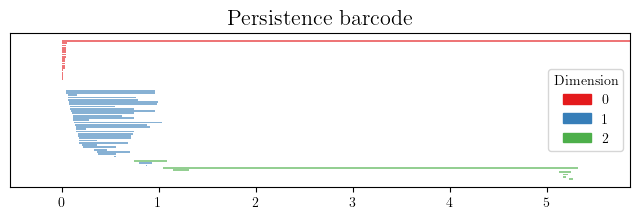

In [80]:
# compute persistence
persistence_diagram = FuzzyCoverPersistence(
    max_dimension=2, log_rescaling=True
).fit_transform(fuzzy_cover)

fig = plt.figure(figsize=(8, 2))
ax = fig.gca()
gudhi.plot_persistence_barcode(persistence_diagram,axes=ax)
plt.savefig(
    "./sphere_barcode"+ ".pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()

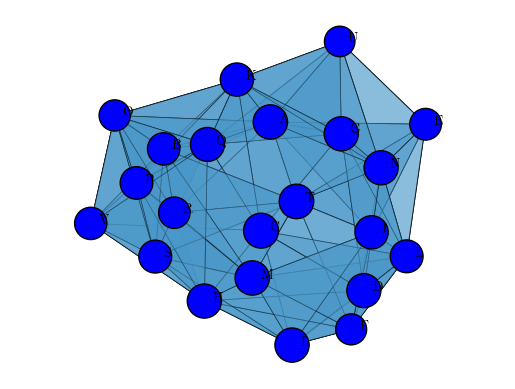

In [59]:
# plot nerve
plot_nerve(fuzzy_cover, threshold=0.2, interactive=False, max_vertex_size=0.1)
plt.show()

In [60]:
# interactive plot nerve
plot_nerve(
    fuzzy_cover,
    threshold=0.2,
    interactive=True,
    max_vertex_size=0.1,
    # requires labels, so using dummy labels
    labels=[0] * len(X),
)

visualizations/pyvis_test.html


# MNIST

/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/luisscoccola/code/shapediscover/venv_main/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


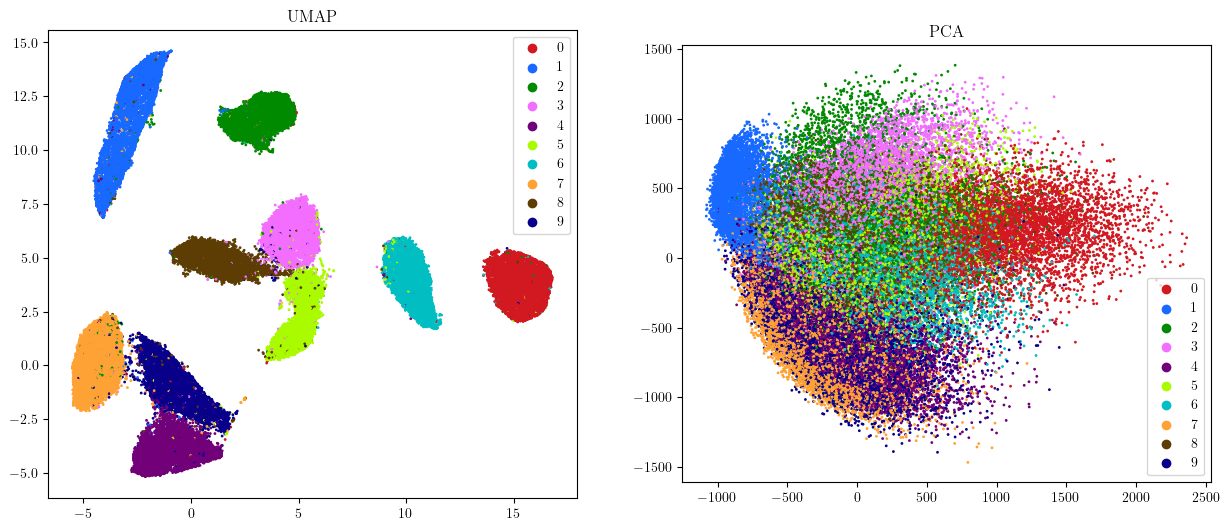

In [66]:
import torchvision

mnist_dataset = torchvision.datasets.MNIST(root="./datasets", download=True)
mnist_array = np.array(
    [np.array(image_label[0]).flatten() for image_label in mnist_dataset]
)
mnist_labels = np.array([image_label[1] for image_label in mnist_dataset])

X = mnist_array
y = mnist_labels

X_umap, X_pca = plot_and_return_2d_embedding(X, y=y)

In [67]:
coverer = ShapeDiscoverLite(10,regularization=40)
fuzzy_cover = coverer.fit_transform(X)

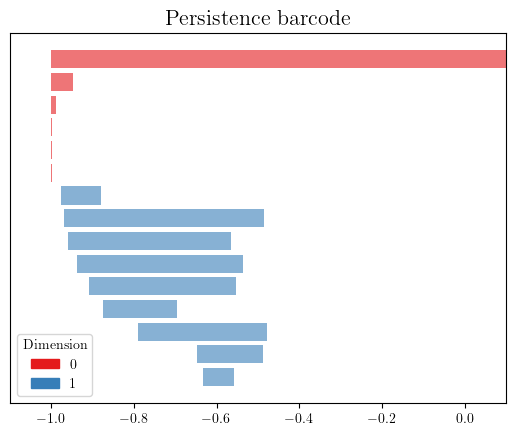

In [68]:
persistence_diagram = FuzzyCoverPersistence(
    max_dimension=1, log_rescaling=False
).fit_transform(fuzzy_cover)
gudhi.plot_persistence_barcode(persistence_diagram)
plt.show()

In [69]:
plot_nerve(
    fuzzy_cover,
    threshold=0.8,
    interactive=True,
    max_vertex_size=0.8,
    labels=y,
)

visualizations/pyvis_test.html
